In [11]:
## SUPERMARKET_SALES ##

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**PROBLEM STATEMENT**

How can this supermarket chain understand what drives customer satisfaction and revenue performance across its branches, product lines, and customer segments — and use those insights to optimise staffing, inventory, and marketing?




In [9]:
Sales = pd.read_csv('/content/supermarket_sales - Sheet1.csv')

In [10]:
Sales.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [12]:
Sales.shape

(1000, 17)

In [13]:
# Obtaining datatypes and Null values
Sales.info()

# Observed: No Null. Datatypes requires changes for Date & Time.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [14]:
# Check what they look like raw
print(Sales['Date'].head())
print(Sales['Time'].head())
print()
print(Sales['Date'].dtype)
print(Sales['Time'].dtype)

0     1/5/2019
1     3/8/2019
2     3/3/2019
3    1/27/2019
4     2/8/2019
Name: Date, dtype: object
0    13:08
1    10:29
2    13:23
3    20:33
4    10:37
Name: Time, dtype: object

object
object


In [15]:
# Converting Date and Time datatypes

Sales['Date'] = pd.to_datetime(Sales['Date'], format='%m/%d/%Y')
Sales['Hour'] = pd.to_datetime(Sales['Time'], format='%H:%M').dt.hour

print(Sales['Date'].dtype)
print(Sales['Hour'].head())

datetime64[ns]
0    13
1    10
2    13
3    20
4    10
Name: Hour, dtype: int32


In [23]:
# Setting date as Index
sales.set_index('Date', inplace=True)
sales.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour
Date,,,,,,,,,,,,,,,,,
2019-01-05,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1,13
2019-03-08,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6,10
2019-03-03,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4,13
2019-01-27,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4,20
2019-02-08,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3,10


In [16]:
sales.describe()

NameError: name 'sales' is not defined

In [17]:

#NEED TO RELOOK INTO THIS
import pandas as pd

Sales = pd.read_csv('/content/supermarket_sales - Sheet1.csv')

# Convert Date properly
Sales['Date'] = pd.to_datetime(Sales['Date'], format='%m/%d/%Y')

# Extract Hour directly from Time
Sales['Hour'] = pd.to_datetime(Sales['Time'], format='%H:%M').dt.hour

# Feature Engineering
Sales['Month'] = Sales['Date'].dt.month
Sales['Day_of_Week'] = Sales['Date'].dt.dayofweek
Sales['Week'] = Sales['Date'].dt.isocalendar().week
Sales['Time_of_Day'] = pd.cut(Sales['Hour'],
                               bins=[9, 12, 17, 21],
                               labels=['Morning', 'Afternoon', 'Evening'])

# Drop useless column
Sales.drop(columns=['gross margin percentage'], inplace=True)

print(Sales.shape)
print(Sales.columns.tolist())

(1000, 21)
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross income', 'Rating', 'Hour', 'Month', 'Day_of_Week', 'Week', 'Time_of_Day']


In [18]:
# First check what dtype it currently is
print(Sales['Time'].dtype)
print(Sales['Time'].head())

object
0    13:08
1    10:29
2    13:23
3    20:33
4    10:37
Name: Time, dtype: object


In [19]:
# Univariate Analysis

Sales[['Unit price', 'Quantity', 'Total', 'gross income', 'Rating']].describe()

,Unit price,Quantity,Total,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,322.966749,15.379369,6.97270
std,26.494628,2.923431,245.885335,11.708825,1.71858
min,10.080000,1.000000,10.678500,0.508500,4.00000
25%,32.875000,3.000000,124.422375,5.924875,5.50000
50%,55.230000,5.000000,253.848000,12.088000,7.00000
75%,77.935000,8.000000,471.350250,22.445250,8.50000
max,99.960000,10.000000,1042.650000,49.650000,10.00000


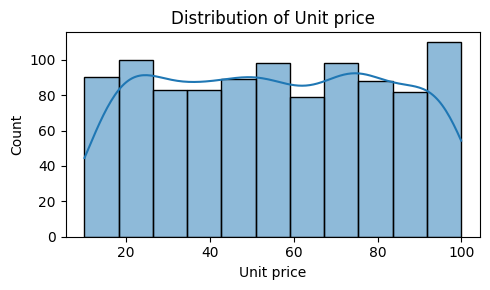

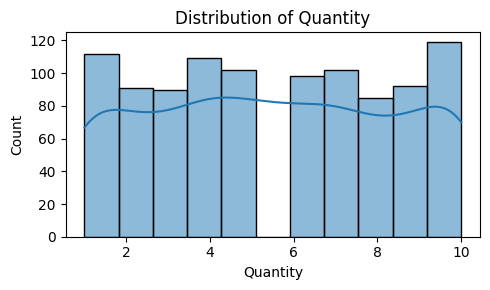

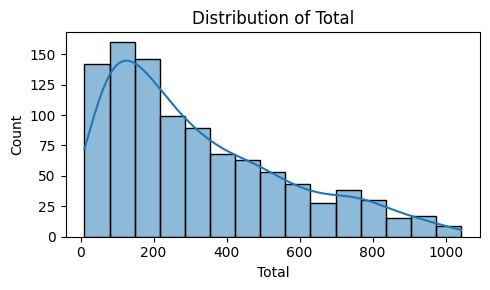

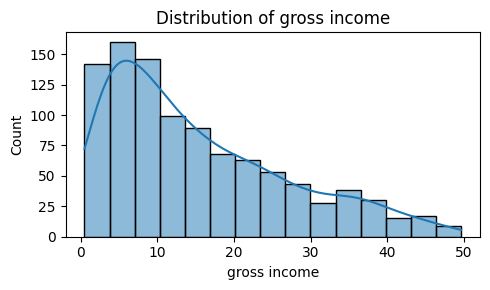

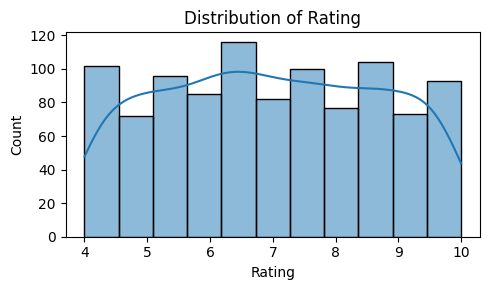

In [68]:
# Plotting based on Distributions

cols = ['Unit price', 'Quantity', 'Total', 'gross income', 'Rating']

for col in cols:
    plt.figure(figsize=(5,3))
    sns.histplot(Sales[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

#Observation
#Unit Price — fairly flat/uniform, meaning prices are spread evenly from $10 to $100. No price range dominates.
#Quantity — also fairly flat, customers buy anywhere from 1 to 10 items fairly equally. No strong preference.
#Total —  It's right skewed — most transactions are low value (under $200) but a few go up to $1,000.
  #This is very typical retail behaviour.
#Gross Income — will look identical to Total because it's directly calculated from it.

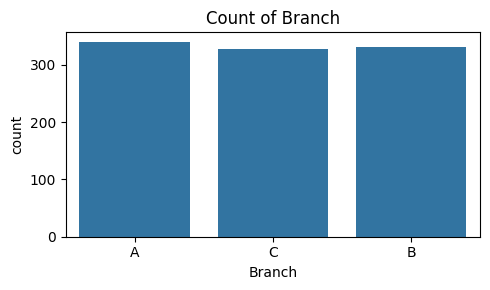

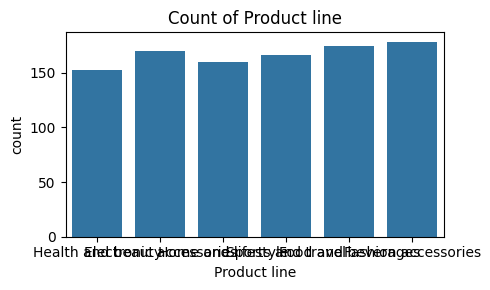

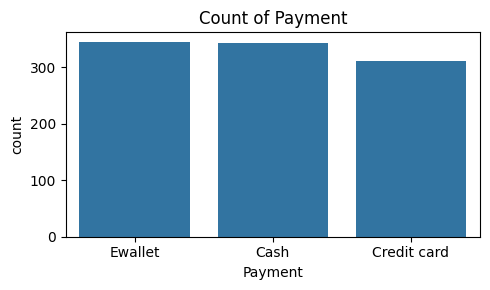

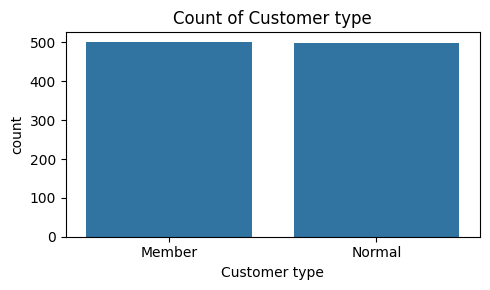

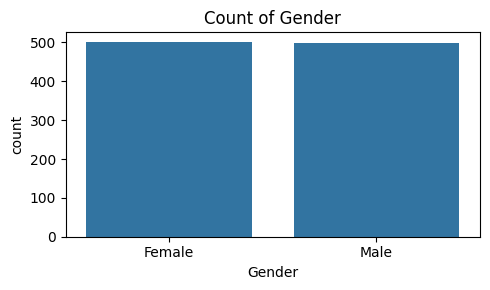

In [67]:
# Plotting based on Categories

cat_cols = ['Branch', 'Product line', 'Payment', 'Customer type', 'Gender']

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=Sales, x=col)
    plt.title(f'Count of {col}')
    plt.tight_layout()
    plt.show()

# OBSERVATIONS
#No single branch dominates.
#No product line massively outsells others.
#Payment methods are nearly equal.

/tmp/ipykernel_826/3674699003.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Branch', y='Total', estimator=sum, ci=None)


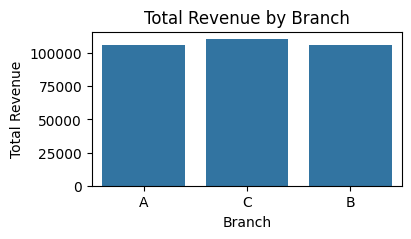

In [22]:
# BIVARIATE ANALYSIS
# Plotting Revenue VS Branch

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Branch', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Branch')
plt.ylabel('Total Revenue')
plt.show()

/tmp/ipykernel_826/2005366395.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Branch', y='Rating', ci=None)


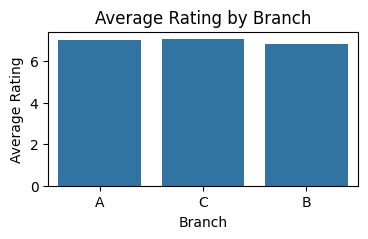

In [23]:
# Plotting Revenue VS Branch

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Branch', y='Rating', ci=None)
plt.title('Average Rating by Branch')
plt.ylabel('Average Rating')
plt.show()

In [ ]:
# OBSERVATIONS:

#Branch C leads on both revenue and satisfaction

/tmp/ipykernel_826/1343661983.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Product line', y='Total', estimator=sum, ci=None)


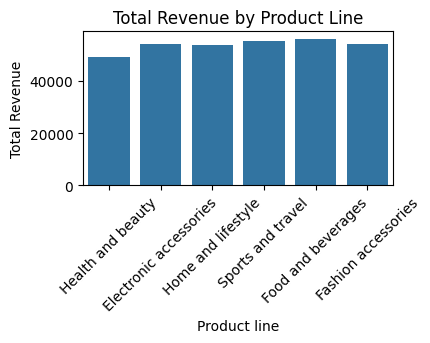

In [24]:
# Plotting Revenue by Product Line

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Product line', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Product Line')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_826/24612169.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Product line', y='Rating', ci=None)


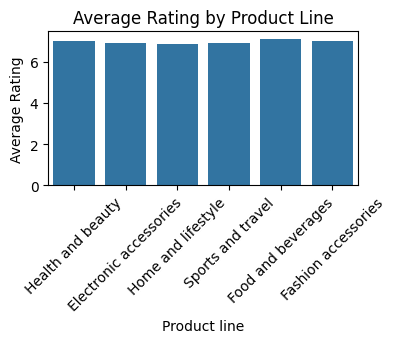

In [25]:
# Plotting Rating by Product Line
plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Product line', y='Rating', ci=None)
plt.title('Average Rating by Product Line')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [37]:
# OBSERVATIONS:

#Food & Beverages tops both revenue and rating — consistent with Branch C's pattern.
#But Health & Beauty is the flip — it's last in revenue yet second highest in rating.
   #Customers love it but aren't buying as much of it.

/tmp/ipykernel_826/3380312388.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Customer type', y='Total', estimator=sum, ci=None)


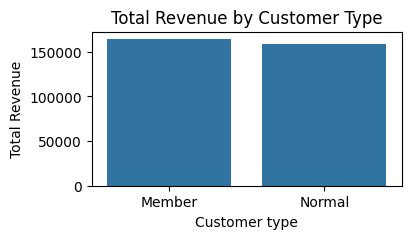

In [26]:
# CUSTOMER BEHAVIOUR

# Customer type

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Customer type', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Customer Type')
plt.ylabel('Total Revenue')
plt.show()

/tmp/ipykernel_826/3071427418.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Gender', y='Total', estimator=sum, ci=None)


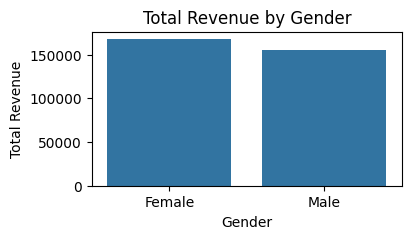

In [27]:
# Gender

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Gender', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Gender')
plt.ylabel('Total Revenue')
plt.show()

/tmp/ipykernel_826/2288460791.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Payment', y='Total', estimator=sum, ci=None)


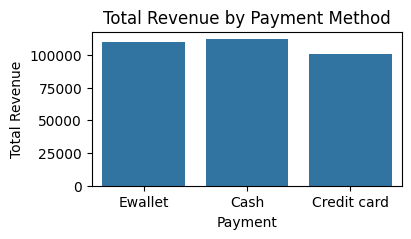

In [28]:
# Payment Type

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Payment', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Payment Method')
plt.ylabel('Total Revenue')
plt.show()

In [41]:
# OBSERVATIONS
# Members purchasing slightly Higher
# Slighly more female purchasing
# Payment type cash and ewallet preferred.

/tmp/ipykernel_826/1927012413.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Hour', y='Total', estimator=sum, ci=None)


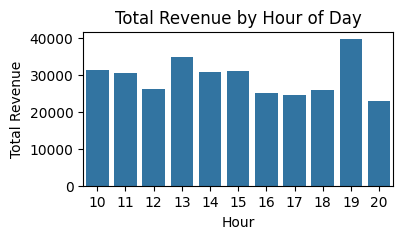

In [29]:
# TIME PATTERNS

# Revenue By Hour of Day

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Hour', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Hour of Day')
plt.ylabel('Total Revenue')
plt.show()

/tmp/ipykernel_826/809463202.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Day_of_Week', y='Total', estimator=sum, ci=None)


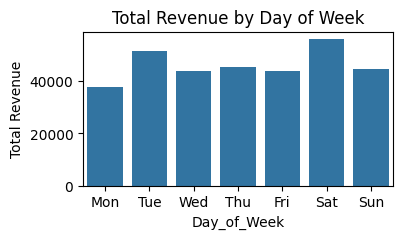

In [30]:
# Revenue By Day of Week

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Day_of_Week', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.show()

/tmp/ipykernel_826/2893659028.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=Sales, x='Month', y='Total', estimator=sum, ci=None)


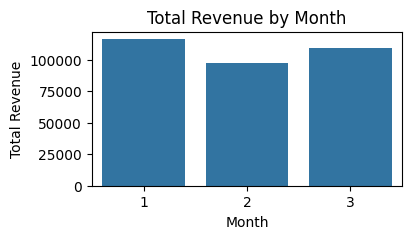

In [31]:
# Revenue By Month

plt.figure(figsize=(4,2))
sns.barplot(data=Sales, x='Month', y='Total', estimator=sum, ci=None)
plt.title('Total Revenue by Month')
plt.ylabel('Total Revenue')
plt.show()

In [ ]:
# OBSERVATIONS
#Peak trading on Saturday evenings in January

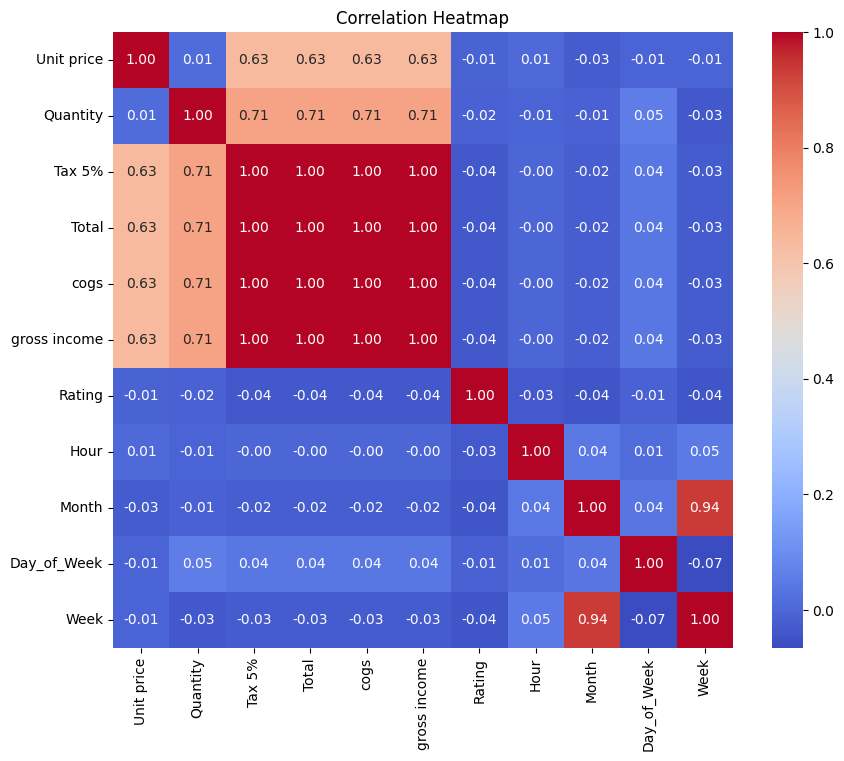

In [32]:
#CORRELATION HEATMAP

plt.figure(figsize=(10,8))
sns.heatmap(Sales.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# OBSERVATION
# Quantity (0.74) influences Total more than Unit Price (0.63),
  #meaning how much people buy matters more than what they pay per item.

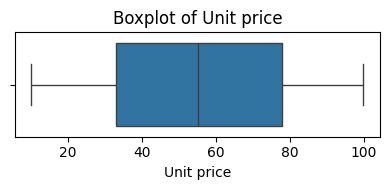

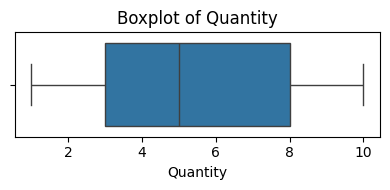

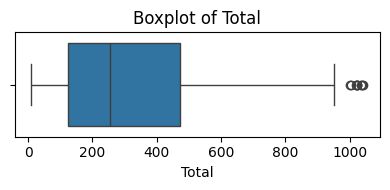

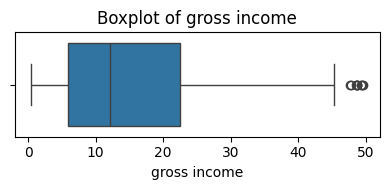

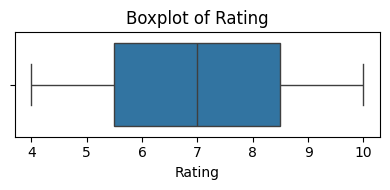

In [66]:
# OUTLIERS

cols = ['Unit price', 'Quantity', 'Total', 'gross income', 'Rating']

for col in cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=Sales[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [34]:
#IQR for Outliers

cols = ['Total', 'gross income']

for col in cols:
    Q1 = Sales[col].quantile(0.25)
    Q3 = Sales[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = Sales[(Sales[col] < lower) | (Sales[col] > upper)]

    print(f'{col}:')
    print(f'  Lower bound: {lower:.2f}')
    print(f'  Upper bound: {upper:.2f}')
    print(f'  Number of outliers: {len(outliers)}')
    print(f'  Outlier values: {outliers[col].values}')
    print()

Total:
  Lower bound: -395.97
  Upper bound: 991.74
  Number of outliers: 9
  Outlier values: [1003.59  1039.29  1042.65  1002.12  1020.705 1034.46  1023.75  1022.385
 1022.49 ]

gross income:
  Lower bound: -18.86
  Upper bound: 47.23
  Number of outliers: 9
  Outlier values: [47.79  49.49  49.65  47.72  48.605 49.26  48.75  48.685 48.69 ]



In [35]:
print(f'Outliers are only {9/len(Sales)*100:.1f}% of your data')
print('Values are realistic for a supermarket transaction')
print('Removing them would bias your analysis against high value customers')

# OBSERVATIONS
# 9 high value transaction. identified above $991 in Total sales.
# These are retained as they represent genuine customer behaviour rather than data errors.

Outliers are only 0.9% of your data
Values are realistic for a supermarket transaction
Removing them would bias your analysis against high value customers


In [36]:
# Full details of these 9 transactions
outliers = Sales[(Sales['Total'] > 991.74)]
print(outliers[['Branch', 'Product line', 'Customer type',
                'Gender', 'Unit price', 'Quantity',
                'Total', 'gross income', 'Rating']].to_string())

    Branch         Product line Customer type  Gender  Unit price  Quantity     Total  gross income  Rating
166      C   Home and lifestyle        Normal    Male       95.58        10  1003.590        47.790     4.8
167      A  Fashion accessories        Normal    Male       98.98        10  1039.290        49.490     8.7
350      C  Fashion accessories        Member  Female       99.30        10  1042.650        49.650     6.6
357      C    Sports and travel        Normal  Female       95.44        10  1002.120        47.720     5.2
422      C  Fashion accessories        Member  Female       97.21        10  1020.705        48.605     8.7
557      C   Food and beverages        Member  Female       98.52        10  1034.460        49.260     4.5
699      C   Home and lifestyle        Normal    Male       97.50        10  1023.750        48.750     8.0
792      B   Home and lifestyle        Normal  Female       97.37        10  1022.385        48.685     4.9
996      B   Home and lifest

In [37]:
#Saving New Cleaned Dataset
Sales.to_csv('/content/supermarket_sales_cleaned.csv', index=True)

In [38]:
# Verify it saved correctly
import os
print(os.path.getsize('/content/supermarket_sales_cleaned.csv'), 'bytes')
print(Sales.shape)
print(Sales.columns.tolist())

142264 bytes
(1000, 21)
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross income', 'Rating', 'Hour', 'Month', 'Day_of_Week', 'Week', 'Time_of_Day']


In [ ]:
# ================================
#  MACHINE LEARNING
# ================================

In [39]:
print(Sales.columns.tolist())

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross income', 'Rating', 'Hour', 'Month', 'Day_of_Week', 'Week', 'Time_of_Day']


In [40]:
# Define features and target
features = ['Branch', 'Gender', 'Product line', 'Unit price',
            'Quantity', 'Total', 'Payment', 'Hour',
            'Month', 'Day_of_Week', 'Rating']

target = 'Customer type'

# Create X and y
X = Sales[features]
y = Sales[target]

# Check shapes
print('Features shape:', X.shape)
print('Target shape:', y.shape)
print()
print('Target distribution:')
print(y.value_counts())

Features shape: (1000, 11)
Target shape: (1000,)

Target distribution:
Customer type
Member    501
Normal    499
Name: count, dtype: int64


In [41]:
# Encode categorical columns
le = LabelEncoder()

X = X.copy()
cat_cols = ['Branch', 'Gender', 'Product line', 'Payment']

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Encode target
y = le.fit_transform(y)

print('Encoding done!')
print(X.head())

Encoding done!
   Branch  Gender  Product line  Unit price  Quantity     Total  Payment  \
0       0       0             3       74.69         7  548.9715        2   
1       2       0             0       15.28         5   80.2200        0   
2       0       1             4       46.33         7  340.5255        1   
3       0       1             3       58.22         8  489.0480        2   
4       0       1             5       86.31         7  634.3785        2   

   Hour  Month  Day_of_Week  Rating  
0    13      1            5     9.1  
1    10      3            4     9.6  
2    13      3            6     7.4  
3    20      1            6     8.4  
4    10      2            4     5.3  


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (800, 11)
Testing set size: (200, 11)


In [43]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Evaluate
print('=== Logistic Regression Results ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, lr_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, lr_pred))

=== Logistic Regression Results ===
Accuracy: 0.5600
F1 Score: 0.5464

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.61      0.57        97
           1       0.58      0.51      0.55       103

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.56      0.56      0.56       200



In [44]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
print('=== Random Forest Results ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, rf_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, rf_pred))

=== Random Forest Results ===
Accuracy: 0.4750
F1 Score: 0.4444

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.55      0.50        97
           1       0.49      0.41      0.44       103

    accuracy                           0.47       200
   macro avg       0.48      0.48      0.47       200
weighted avg       0.48      0.47      0.47       200



In [ ]:
# OBSERVATION
# Both Logistic Regression (56%) and Random Forest (47%) failed to predict customer type accurately
#   suggesting membership status is independent of shopping behaviour.

In [45]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain Random Forest on scaled data
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train_scaled, y_train)
rf_pred2 = rf_model2.predict(X_test_scaled)

print('=== Random Forest Scaled Results ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred2):.4f}')
print(f'F1 Score: {f1_score(y_test, rf_pred2):.4f}')

=== Random Forest Scaled Results ===
Accuracy: 0.4900
F1 Score: 0.4796


In [61]:

"""
CLASSIFICATION FINDINGS — Customer Type Prediction

Models tested:
- Logistic Regression: 56% accuracy
- Random Forest (unscaled): 47% accuracy
- Random Forest (scaled): 49% accuracy

Conclusion:
Customer type (Member vs Normal) cannot be reliably predicted
from transaction behaviour. Membership status appears to be
independent of shopping patterns — members and normal customers
shop in virtually identical ways.

Business Insight:
Membership is likely driven by external factors such as
promotions, sign-up incentives or loyalty programmes rather
than shopping behaviour itself.
"""

'\nCLASSIFICATION FINDINGS — Customer Type Prediction\n\nModels tested:\n- Logistic Regression: 56% accuracy\n- Random Forest (unscaled): 47% accuracy  \n- Random Forest (scaled): 49% accuracy\n\nConclusion:\nCustomer type (Member vs Normal) cannot be reliably predicted \nfrom transaction behaviour. Membership status appears to be \nindependent of shopping patterns — members and normal customers \nshop in virtually identical ways.\n\nBusiness Insight:\nMembership is likely driven by external factors such as \npromotions, sign-up incentives or loyalty programmes rather \nthan shopping behaviour itself.\n'

In [46]:
print('Moving to Rating Prediction (Regression)')
print('Target: Predict customer satisfaction score (4-10)')

Moving to Rating Prediction (Regression)
Target: Predict customer satisfaction score (4-10)


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from google.colab import files
uploaded = files.upload()

Saving supermarket_sales - Sheet1.csv to supermarket_sales - Sheet1.csv


In [48]:
Sales.to_csv('/content/drive/MyDrive/supermarket_sales_cleaned.csv', index=False)
print('Saved to Google Drive successfully!')

Saved to Google Drive successfully!


In [49]:
print(Sales.shape)

(1000, 21)


In [51]:
le = LabelEncoder()

features = ['Branch', 'Gender', 'Product line', 'Unit price',
            'Quantity', 'Total', 'Payment', 'Hour',
            'Month', 'Day_of_Week', 'Customer type']

target = 'Rating'

X = Sales[features].copy()
y = Sales[target]

cat_cols = ['Branch', 'Gender', 'Product line', 'Payment', 'Customer type']

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42)

print('Data ready!')
print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)

Data ready!
Training set: (800, 11)
Testing set: (200, 11)


In [52]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Evaluate
print('=== Linear Regression Results ===')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.4f}')
print(f'R2 Score: {r2_score(y_test, lr_pred):.4f}')

=== Linear Regression Results ===
RMSE: 1.7743
R2 Score: -0.0262


In [ ]:
# OBSERVATIONS
# "Linear Regression achieved RMSE of 1.77 and negative R2 — confirming that customer satisfaction cannot be predicted through linear
   # relationships alone."

In [53]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
print('=== Random Forest Regressor Results ===')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}')
print(f'R2 Score: {r2_score(y_test, rf_pred):.4f}')

=== Random Forest Regressor Results ===
RMSE: 1.8311
R2 Score: -0.0930


In [54]:
# Train Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test)

# Evaluate
print('=== Gradient Boosting Results ===')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, gb_pred)):.4f}')
print(f'R2 Score: {r2_score(y_test, gb_pred):.4f}')

=== Gradient Boosting Results ===
RMSE: 1.8528
R2 Score: -0.1190


In [ ]:
"""
REGRESSION FINDINGS — Customer Rating Prediction

Models tested:
- Linear Regression: RMSE 1.77, R2 -0.03
- Random Forest: RMSE 1.83, R2 -0.09
- Gradient Boosting: RMSE 1.85, R2 -0.12

Conclusion:
Customer satisfaction rating cannot be predicted from available
transaction features. All models performed worse than simply
predicting the mean rating for every customer.

This confirms the EDA finding that rating has near-zero
correlation with all financial and categorical variables.

Business Insight:
Factors driving customer satisfaction are likely unmeasured
in this dataset — such as staff behaviour, store cleanliness,
waiting time, or product quality — rather than transaction
details alone.
"""

In [57]:
# Select features for clustering
cluster_features = ['Unit price', 'Quantity', 'Total',
                    'gross income', 'Rating', 'Hour',
                    'Month', 'Day_of_Week']

X_cluster = Sales[cluster_features].copy()

# Scale the data — very important for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print('Data prepared for clustering!')
print('Shape:', X_scaled.shape)

Data prepared for clustering!
Shape: (1000, 8)


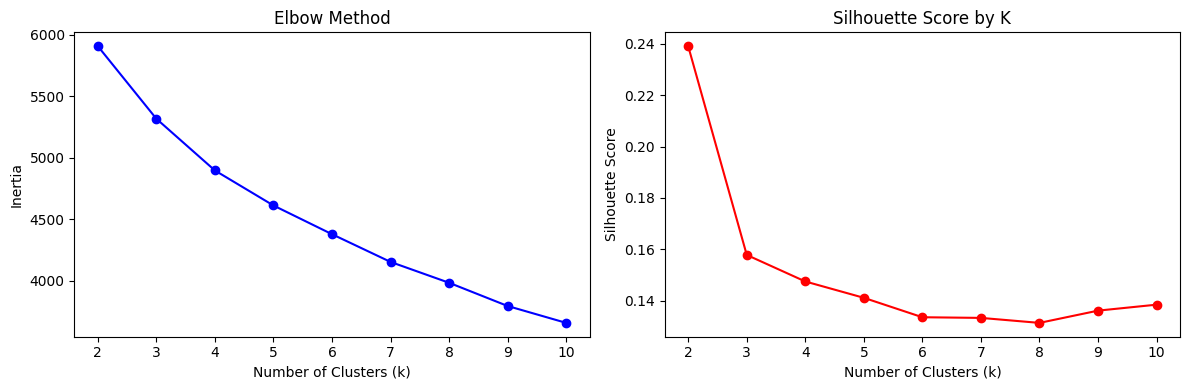


Silhouette Scores:
  k=2: 0.2391
  k=3: 0.1578
  k=4: 0.1475
  k=5: 0.1412
  k=6: 0.1336
  k=7: 0.1333
  k=8: 0.1314
  k=9: 0.1362
  k=10: 0.1385


In [59]:
# Test different numbers of clusters
# Test different numbers of clusters
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')

plt.tight_layout()
plt.show()

print('\nSilhouette Scores:')
for k, score in zip(k_range, silhouette_scores):
    print(f'  k={k}: {score:.4f}')

In [ ]:
# OBSERVATION

KMeans clustering identified 2 distinct customer segments. While silhouette scores indicate weak cluster separation (0.24)
# — consistent with the dataset's uniform distributions observed in EDA — the two segments reveal meaningful
# behavioural differences."

In [60]:
# Compare silhouette scores for k=3 and k=4
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    print(f'k={k}: Silhouette Score = {score:.4f}')

k=2: Silhouette Score = 0.2391
k=3: Silhouette Score = 0.1578
k=4: Silhouette Score = 0.1475


In [62]:
# Train KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to original dataframe
Sales['Cluster'] = kmeans.labels_

# Check cluster sizes
print('Cluster Distribution:')
print(Sales['Cluster'].value_counts())

Cluster Distribution:
Cluster
1    652
0    348
Name: count, dtype: int64


In [63]:
# Compare clusters across key features
cluster_summary = Sales.groupby('Cluster')[['Unit price', 'Quantity',
                                             'Total', 'gross income',
                                             'Rating', 'Hour',
                                             'Month', 'Day_of_Week']].mean().round(2)

print('=== Cluster Summary ===')
print(cluster_summary)

=== Cluster Summary ===
         Unit price  Quantity   Total  gross income  Rating   Hour  Month  \
Cluster                                                                     
0             75.29      7.87  609.29         29.01    6.90  14.95   1.93   
1             45.20      4.25  170.14          8.10    7.01  14.89   2.02   

         Day_of_Week  
Cluster               
0               3.06  
1               3.02  


In [64]:
# Categorical breakdown per cluster
cat_cols = ['Branch', 'Gender', 'Customer type',
            'Product line', 'Payment']

for col in cat_cols:
    print(f'\n{col} by Cluster:')
    print(pd.crosstab(Sales['Cluster'], Sales[col], normalize='index').round(2))


Branch by Cluster:
Branch      A     B     C
Cluster                  
0        0.32  0.33  0.35
1        0.35  0.33  0.32

Gender by Cluster:
Gender   Female  Male
Cluster              
0          0.53  0.47
1          0.49  0.51

Customer type by Cluster:
Customer type  Member  Normal
Cluster                      
0                0.52    0.48
1                0.49    0.51

Product line by Cluster:
Product line  Electronic accessories  Fashion accessories  Food and beverages  \
Cluster                                                                         
0                               0.17                 0.18                0.16   
1                               0.17                 0.18                0.18   

Product line  Health and beauty  Home and lifestyle  Sports and travel  
Cluster                                                                 
0                          0.15                0.16               0.18  
1                          0.15                0.16

In [ ]:
"""
CLUSTERING FINDINGS — Customer Segmentation

Algorithm: KMeans (k=2)
Silhouette Score: 0.2391

Cluster 0 — High Value Customers (34.8% of customers)
- Average transaction: $609.29
- Average quantity: 7.87 items
- Average unit price: $75.29
- Average rating: 6.90

Cluster 1 — Regular Customers (65.2% of customers)
- Average transaction: $170.14
- Average quantity: 4.25 items
- Average unit price: $45.20
- Average rating: 7.01

Key Insight:
High value customers spend 3.5x more per transaction but rate
their experience virtually the same as regular customers.
Demographics (gender, branch, payment method) are similar
across both segments suggesting spending behaviour is
independent of customer profile.
"""



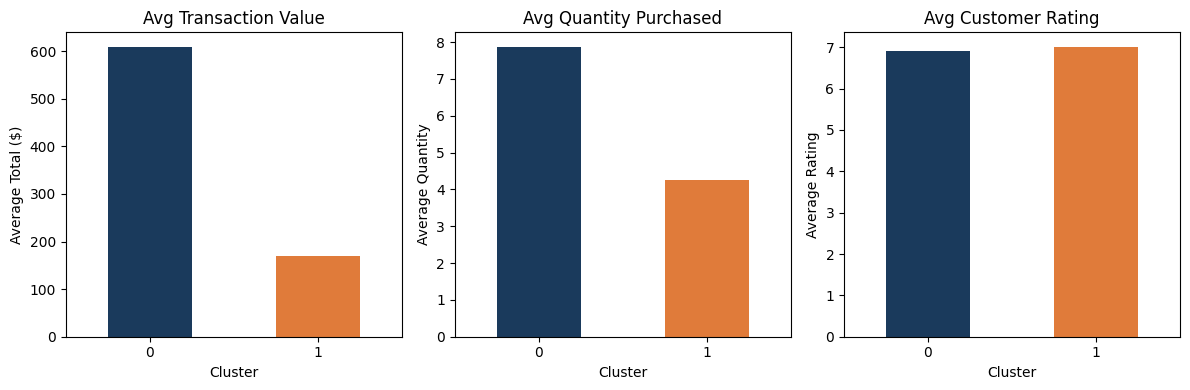

In [65]:
plt.figure(figsize=(12, 4))

# Total spend by cluster
plt.subplot(1, 3, 1)
Sales.groupby('Cluster')['Total'].mean().plot(kind='bar',
                                               color=['#1a3a5c','#e07b3a'])
plt.title('Avg Transaction Value')
plt.ylabel('Average Total ($)')
plt.xticks(rotation=0)

# Quantity by cluster
plt.subplot(1, 3, 2)
Sales.groupby('Cluster')['Quantity'].mean().plot(kind='bar',
                                                  color=['#1a3a5c','#e07b3a'])
plt.title('Avg Quantity Purchased')
plt.ylabel('Average Quantity')
plt.xticks(rotation=0)

# Rating by cluster
plt.subplot(1, 3, 3)
Sales.groupby('Cluster')['Rating'].mean().plot(kind='bar',
                                                color=['#1a3a5c','#e07b3a'])
plt.title('Avg Customer Rating')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
"""
"High value customers spend more and buy more — but are no more satisfied than regular customers.
Satisfaction is driven by something else entirely."